# UMAP on Expresso utterances: cluster by style?

Load Expresso read-speech paths, extract a fixed-size feature per utterance (mel-spectrogram stats or optional encoder), run UMAP to 2D, and plot colored by **style** (and optionally speaker) to see if prosodic styles cluster.

In [64]:
# Run this cell once to install dependencies (uses the kernel's Python)
%pip install librosa umap-learn matplotlib tqdm --quiet

Note: you may need to restart the kernel to use updated packages.


## 1. Setup and collect unique utterances

In [65]:
import os
import json
import numpy as np

# Paths: notebook is in colm/; manifests in interspeech/
_here = os.path.abspath(os.getcwd())
_project = os.path.dirname(_here)
EXPRESSO_ROOT = os.environ.get('EXPRESSO_ROOT', os.path.join(_project, 'expresso'))

# True = use ALL Expresso read-speech files (~11k). False = only pair manifest (~700).
USE_ALL_EXPRESSO = True

if USE_ALL_EXPRESSO:
    EXPRESSO_ALL_MANIFEST = os.path.join(_project, 'interspeech', 'expresso_all.json')
    if os.path.isfile(EXPRESSO_ALL_MANIFEST):
        with open(EXPRESSO_ALL_MANIFEST) as f:
            all_entries = json.load(f)
        utterances = [(e['path'], e['style'], e['speaker']) for e in all_entries]
        print(f'Loaded {len(utterances)} utterances from expresso_all.json')
    else:
        read_dir = os.path.join(EXPRESSO_ROOT, 'audio_48khz', 'read')
        utterances = []
        for speaker in ('ex01', 'ex02', 'ex03', 'ex04'):
            spk_dir = os.path.join(read_dir, speaker)
            if not os.path.isdir(spk_dir):
                continue
            for style in os.listdir(spk_dir):
                for corpus in ('base', 'longform'):
                    corp = os.path.join(spk_dir, style, corpus)
                    if not os.path.isdir(corp):
                        continue
                    for f in os.listdir(corp):
                        if f.endswith('.wav'):
                            utterances.append((os.path.join(corp, f), style, speaker))
        print(f'Scanned {len(utterances)} utterances from {read_dir}')
else:
    EXPRESSO_MANIFEST = os.path.join(_project, 'interspeech', 'expresso_local_2.json')
    if not os.path.isfile(EXPRESSO_MANIFEST):
        EXPRESSO_MANIFEST = os.path.join(_here, 'expresso_local_2.json')
    with open(EXPRESSO_MANIFEST) as f:
        pairs = json.load(f)
    seen = set()
    utterances = []
    for p in pairs:
        for path_key, style_key in [('audio1_path', 'style1'), ('audio2_path', 'style2')]:
            path = p[path_key]
            style = p[style_key]
            if path in seen:
                continue
            seen.add(path)
            parts = path.replace('\\', '/').split('/')
            speaker = next((x for x in parts if x in ('ex01','ex02','ex03','ex04')), 'unknown')
            utterances.append((path, style, speaker))
    print(f'Loaded {len(utterances)} utterances from pair manifest')

# Optional: use only one speaker ('ex01','ex02','ex03','ex04'). None = all speakers.
SPEAKER_FILTER = None  # e.g. 'ex01' for that speaker only
if SPEAKER_FILTER:
    utterances = [u for u in utterances if u[2] == SPEAKER_FILTER]
    print(f'Filtered to speaker {SPEAKER_FILTER}: {len(utterances)} utterances')

print(f'Total utterances: {len(utterances)}')
from collections import Counter
print('By style:', Counter(u[1] for u in utterances))
print('By speaker:', Counter(u[2] for u in utterances))

Loaded 11615 utterances from expresso_all.json
Total utterances: 11615
By style: Counter({'default': 2483, 'confused': 1520, 'enunciated': 1520, 'happy': 1520, 'laughing': 1520, 'sad': 1519, 'whisper': 1518, 'singing': 11, 'narration': 4})
By speaker: Counter({'ex02': 2905, 'ex03': 2905, 'ex04': 2903, 'ex01': 2902})


## 2. Extract features per utterance (mel-spectrogram stats)

In [66]:
import librosa
from tqdm import tqdm

SR = 16000
N_MELS = 80
HOP = 512
MAX_SAMPLES = 16000 * 15  # 15 s cap

def extract_mel_stats(path):
    """One vector: mean and std of mel spectrogram (over time), flattened."""
    y, sr = librosa.load(path, sr=SR, duration=15)
    if len(y) == 0:
        return None
    mel = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=N_MELS, hop_length=HOP)
    mel_db = librosa.power_to_db(mel, ref=np.max)
    mean_mel = mel_db.mean(axis=1)   # (n_mels,)
    std_mel = mel_db.std(axis=1)    # (n_mels,)
    return np.concatenate([mean_mel, std_mel])  # (2 * n_mels,)

# Subsample if too many (for quick run)
MAX_UTTERANCES = None  # set to None to use all
if MAX_UTTERANCES and len(utterances) > MAX_UTTERANCES:
    rng = np.random.default_rng(42)
    idx = rng.choice(len(utterances), MAX_UTTERANCES, replace=False)
    utterances_sub = [utterances[i] for i in np.sort(idx)]
else:
    utterances_sub = utterances

features = []
labels_style = []
labels_speaker = []
valid_paths = []
for path, style, speaker in tqdm(utterances_sub, desc='Extracting mel stats'):
    if not os.path.isfile(path):
        continue
    feat = extract_mel_stats(path)
    if feat is None:
        continue
    features.append(feat)
    labels_style.append(style)
    labels_speaker.append(speaker)
    valid_paths.append(path)

X = np.stack(features)
print(f'Feature matrix: {X.shape}')

Extracting mel stats: 100%|██████████████| 11615/11615 [01:25<00:00, 135.22it/s]

Feature matrix: (11615, 160)


## 3. UMAP to 2D

In [80]:
import umap

# Tune these based on your plot:
# - Points too scattered? Try n_neighbors=30, min_dist=0.0
# - Clusters too mushed? Try n_neighbors=5, min_dist=0.3
# - metric: 'cosine' (good for high-dim) or 'euclidean'
N_NEIGHBORS = 10
MIN_DIST = 0.0
METRIC = 'cosine'

reducer = umap.UMAP(n_components=2, n_neighbors=N_NEIGHBORS, min_dist=MIN_DIST, metric=METRIC, random_state=42)
embedding = reducer.fit_transform(X)
print('UMAP embedding shape:', embedding.shape)

/ocean/projects/cis220031p/bkoduru/conda/envs/colm/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


UMAP embedding shape: (11615, 2)


**Why do "by style" and "by speaker" look so similar?**

1. **Same positions** — Both panels use the *same* 2D UMAP embedding; only the **colors** change (style vs speaker).
2. **Mel features favor speaker** — Mean/std mel spectrograms capture **voice** (pitch, timbre) much more than **prosodic style**. So UMAP tends to cluster by **speaker**; style is mixed within each cluster. Result: when you color by speaker you see clean clusters; when you color by style you see 7 colors spread over the same clusters, so the overall "shape" looks the same.
3. **To see style separate from speaker** — Use encoder embeddings (Section 5) or features that normalize by speaker / focus on prosody (e.g. pitch contours, energy dynamics) so style can dominate over voice.

In [81]:
# Check: speaker vs style in your sample (each cell = count; rows=speaker, cols=style)
from collections import defaultdict
tab = defaultdict(lambda: defaultdict(int))
for s, sp in zip(labels_style, labels_speaker):
    tab[sp][s] += 1
styles_ord = sorted(set(labels_style))
speakers_ord = sorted(set(labels_speaker))
print('Counts (speaker × style):', ' '.join(f'{s:>10}' for s in styles_ord))
for sp in speakers_ord:
    print(sp, ' '.join(f'{tab[sp][s]:>10}' for s in styles_ord))
print('\n=> Same point positions in both panels; only colors change. Mel features favor speaker (voice), so layout clusters by speaker.')

Counts (speaker × style):   confused    default enunciated      happy   laughing  narration        sad    singing    whisper
ex01        380        620        380        380        380          1        379          3        379
ex02        380        621        380        380        380          1        380          3        380
ex03        380        621        380        380        380          1        380          3        380
ex04        380        621        380        380        380          1        380          2        379

=> Same point positions in both panels; only colors change. Mel features favor speaker (voice), so layout clusters by speaker.


## 4. Plot: colored by style (and by speaker)

/ocean/projects/cis220031p/bkoduru/tmp/ipykernel_91720/2296696272.py:14: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  axes[0].scatter(embedding[mask, 0], embedding[mask, 1], label=s, alpha=0.7, s=PT_SIZE, c=colors_style[i])
/ocean/projects/cis220031p/bkoduru/tmp/ipykernel_91720/2296696272.py:26: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  axes[1].scatter(embedding[mask, 0], embedding[mask, 1], label=s, alpha=0.7, s=PT_SIZ

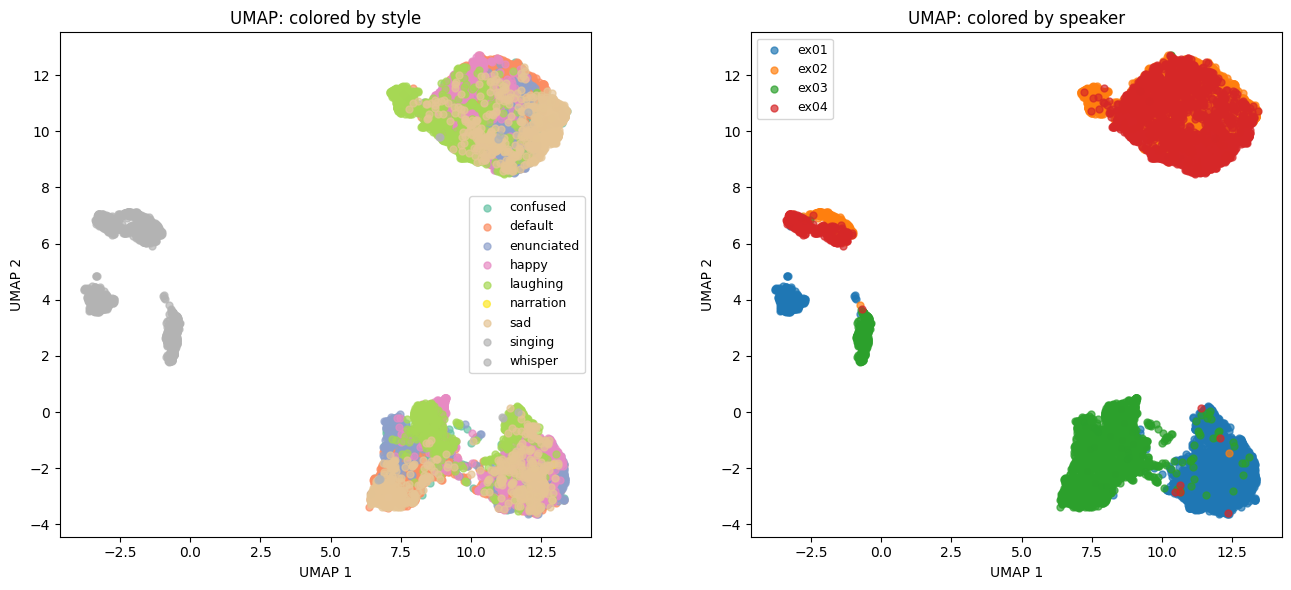

Saved: expresso_umap_by_style_and_speaker.png


In [82]:
import matplotlib.pyplot as plt

# Point size and figure size (increase if overlapping)
PT_SIZE = 25
FIG_W, FIG_H = 14, 6

fig, axes = plt.subplots(1, 2, figsize=(FIG_W, FIG_H))

# By style (7 styles: use distinct colors)
styles = sorted(set(labels_style))
colors_style = plt.cm.Set2(np.linspace(0, 1, max(len(styles), 8)))[:len(styles)]
for i, s in enumerate(styles):
    mask = [l == s for l in labels_style]
    axes[0].scatter(embedding[mask, 0], embedding[mask, 1], label=s, alpha=0.7, s=PT_SIZE, c=colors_style[i])
axes[0].set_title('UMAP: colored by style')
axes[0].legend(loc='best', fontsize=9)
axes[0].set_xlabel('UMAP 1')
axes[0].set_ylabel('UMAP 2')
axes[0].set_aspect('equal')

# By speaker
speakers = sorted(set(labels_speaker))
colors_speaker = plt.cm.tab10(np.linspace(0, 1, max(len(speakers), 10)))[:len(speakers)]
for i, s in enumerate(speakers):
    mask = [l == s for l in labels_speaker]
    axes[1].scatter(embedding[mask, 0], embedding[mask, 1], label=s, alpha=0.7, s=PT_SIZE, c=colors_speaker[i])
axes[1].set_title('UMAP: colored by speaker')
axes[1].legend(loc='best', fontsize=9)
axes[1].set_xlabel('UMAP 1')
axes[1].set_ylabel('UMAP 2')
axes[1].set_aspect('equal')

plt.tight_layout()
plt.savefig('expresso_umap_by_style_and_speaker.png', dpi=150)
plt.show()
print('Saved: expresso_umap_by_style_and_speaker.png')

## 5. Optional: use encoder embeddings instead of mel stats

For a stronger prosodic representation, use a pretrained encoder (e.g. Qwen2-Audio encoder or WavLM) and replace `X` with mean-pooled hidden states. Then re-run UMAP and the same plots. Example stub below.

In [70]:
# Uncomment and run if you have transformers + GPU; then use X_encoder in UMAP instead of X.
# import torch
# from transformers import Qwen2AudioForConditionalGeneration, AutoProcessor
# model_name = 'Qwen/Qwen2-Audio-7B-Instruct'
# processor = AutoProcessor.from_pretrained(model_name)
# model = Qwen2AudioForConditionalGeneration.from_pretrained(model_name, torch_dtype=torch.float16, device_map='auto')
# model.eval()
# encoder = model.audio_tower
# def extract_encoder(path):
#     y, _ = librosa.load(path, sr=16000)
#     inputs = processor.feature_extractor(y, sampling_rate=16000, return_tensors='pt').to(model.device)
#     with torch.no_grad(): out = encoder(**inputs)
#     return out.last_hidden_state[0].mean(dim=0).cpu().numpy()
# X_encoder = np.stack([extract_encoder(p) for p in tqdm(valid_paths[:500])])  # subset for speed
# # Then: reducer.fit_transform(X_encoder) and same plots with labels_style/labels_speaker for that subset
print('Optional: use encoder embeddings (see comments above) for prosody-rich features.')

Optional: use encoder embeddings (see comments above) for prosody-rich features.
